# Insurance Claim Risk & Premium Predictor

## Project Objective

This project aims to develop machine learning models for analyzing insurance customer data and predicting two key outcomes:

1. Insurance premium amount using a regression model.
2. Claim risk using a classification model.

The project involves data generation, exploratory data analysis, preprocessing, model training, and evaluation using appropriate machine learning metrics.

## Dataset

The dataset used in this project is a synthetically generated insurance customer dataset.

It contains information about insurance customers, their demographics, health and lifestyle factors, policy details, and claim history.

The dataset is used for two machine learning tasks:

- **Regression:** Predict the insurance premium amount.
- **Classification:** Predict whether a customer is at high risk of making an insurance claim.

### Data Generation

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 2000

data = {
    "age": np.random.randint(18, 71, n_samples),
    "bmi": np.round(np.random.uniform(18.5, 40.0, n_samples), 1),
    "dependents": np.random.randint(0, 5, n_samples),
    "smoker": np.random.choice(["Yes", "No"], n_samples, p=[0.2, 0.8]),
    "policy_type": np.random.choice(
        ["Basic", "Standard", "Comprehensive"],
        n_samples,
        p=[0.3, 0.5, 0.2]
    ),
    "claim_history": np.random.randint(0, 5, n_samples),
    "annual_income": np.random.randint(200000, 2000001, n_samples),
    "coverage_amount": np.random.randint(500000, 5000001, n_samples)
}

df = pd.DataFrame(data)

In [2]:
df.head()

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount
0,56,38.9,1,No,Standard,3,1818755,651521
1,69,21.7,0,No,Standard,1,246901,2376213
2,46,27.8,0,No,Standard,4,1725304,4690198
3,32,38.8,2,No,Basic,2,566056,3131866
4,60,27.5,1,No,Standard,1,795350,3046946


In [3]:
risk_score = (
    0.025 * df["age"]
    + 0.06 * df["bmi"]
    + 0.7 * df["claim_history"]
    + 1.2 * (df["smoker"] == "Yes")
    + 0.3 * df["dependents"]
)

risk_probability = 1 / (1 + np.exp(-(risk_score - 5.5)))

df["claim_risk"] = np.random.binomial(1, risk_probability)

In [4]:
df["claim_risk"].value_counts()

claim_risk
0    1118
1     882
Name: count, dtype: int64

In [5]:
base_premium = (
    5000
    + 120 * df["age"]
    + 250 * df["bmi"]
    + 1500 * df["claim_history"]
    + 8000 * (df["smoker"] == "Yes")
    + 0.01 * df["coverage_amount"]
    + 0.001 * df["annual_income"]
)

policy_factor = df["policy_type"].map({
    "Basic": 0.8,
    "Standard": 1.0,
    "Comprehensive": 1.3
})

df["premium_amount"] = np.round(
    base_premium * policy_factor + np.random.normal(0, 3000, n_samples),
    2
)

In [6]:
df.head()

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
0,56,38.9,1,No,Standard,3,1818755,651521,1,33181.19
1,69,21.7,0,No,Standard,1,246901,2376213,0,40770.68
2,46,27.8,0,No,Standard,4,1725304,4690198,0,76464.27
3,32,38.8,2,No,Basic,2,566056,3131866,1,41582.23
4,60,27.5,1,No,Standard,1,795350,3046946,1,46261.66


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              2000 non-null   int32  
 1   bmi              2000 non-null   float64
 2   dependents       2000 non-null   int32  
 3   smoker           2000 non-null   str    
 4   policy_type      2000 non-null   str    
 5   claim_history    2000 non-null   int32  
 6   annual_income    2000 non-null   int32  
 7   coverage_amount  2000 non-null   int32  
 8   claim_risk       2000 non-null   int32  
 9   premium_amount   2000 non-null   float64
dtypes: float64(2), int32(6), str(2)
memory usage: 109.5 KB


In [8]:
df.describe()

,age,bmi,dependents,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
count,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2000.000000,2000.000000
mean,44.376500,29.238250,2.022500,2.014500,1.100547e+06,2.791006e+06,0.441000,51534.069060
std,15.226644,6.217421,1.408185,1.418907,5.189171e+05,1.321126e+06,0.496631,16894.082869
min,18.000000,18.500000,0.000000,0.000000,2.009030e+05,5.016580e+05,0.000000,13860.460000
25%,31.000000,23.900000,1.000000,1.000000,6.598282e+05,1.652362e+06,0.000000,38979.317500
50%,45.000000,29.300000,2.000000,2.000000,1.099963e+06,2.832750e+06,0.000000,49896.765000
75%,57.000000,34.500000,3.000000,3.000000,1.551145e+06,3.957255e+06,1.000000,62345.390000
max,70.000000,40.000000,4.000000,4.000000,1.999995e+06,4.999435e+06,1.000000,101554.700000


In [9]:
df.to_csv("insurance_claim_data.csv", index=False)

In [10]:
df.shape

(2000, 10)

## Exploratory Data Analysis

### Understanding the Dataset

In [11]:
df.head()

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
0,56,38.9,1,No,Standard,3,1818755,651521,1,33181.19
1,69,21.7,0,No,Standard,1,246901,2376213,0,40770.68
2,46,27.8,0,No,Standard,4,1725304,4690198,0,76464.27
3,32,38.8,2,No,Basic,2,566056,3131866,1,41582.23
4,60,27.5,1,No,Standard,1,795350,3046946,1,46261.66


In [12]:
df.shape

(2000, 10)

In [13]:
df.columns

Index(['age', 'bmi', 'dependents', 'smoker', 'policy_type', 'claim_history',
       'annual_income', 'coverage_amount', 'claim_risk', 'premium_amount'],
      dtype='str')

### Distribution of Categorical Variables

In [14]:
df['smoker'].value_counts()

smoker
No     1598
Yes     402
Name: count, dtype: int64

In [15]:
df['policy_type'].value_counts()

policy_type
Standard         994
Basic            584
Comprehensive    422
Name: count, dtype: int64

In [16]:
df['claim_risk'].value_counts()

claim_risk
0    1118
1     882
Name: count, dtype: int64

In [17]:
df['claim_history'].value_counts().sort_index()

claim_history
0    396
1    405
2    378
3    416
4    405
Name: count, dtype: int64

### Visualizing Policyholder Categories

In [18]:
import matplotlib.pyplot as plt

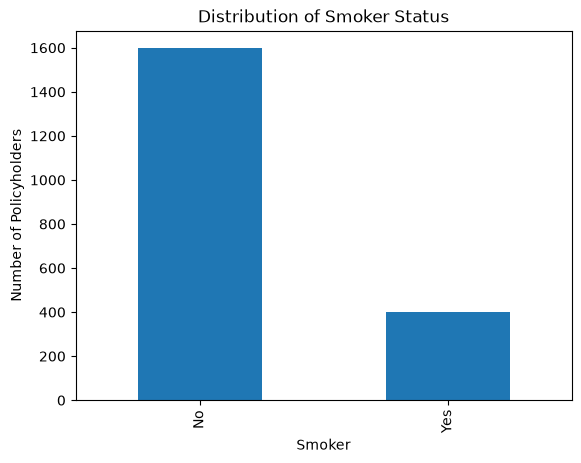

In [19]:
df['smoker'].value_counts().plot(kind='bar')
plt.title('Distribution of Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Number of Policyholders')
plt.show()

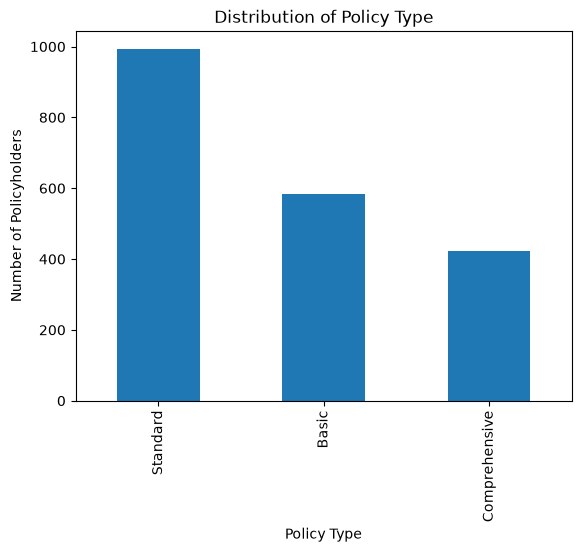

In [20]:
df['policy_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Policy Type')
plt.xlabel('Policy Type')
plt.ylabel('Number of Policyholders')
plt.show()

### Distribution of Numerical Variables

In [21]:
df[['age', 'bmi', 'annual_income', 'coverage_amount', 'premium_amount']].describe()

,age,bmi,annual_income,coverage_amount,premium_amount
count,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2000.000000
mean,44.376500,29.238250,1.100547e+06,2.791006e+06,51534.069060
std,15.226644,6.217421,5.189171e+05,1.321126e+06,16894.082869
min,18.000000,18.500000,2.009030e+05,5.016580e+05,13860.460000
25%,31.000000,23.900000,6.598282e+05,1.652362e+06,38979.317500
50%,45.000000,29.300000,1.099963e+06,2.832750e+06,49896.765000
75%,57.000000,34.500000,1.551145e+06,3.957255e+06,62345.390000
max,70.000000,40.000000,1.999995e+06,4.999435e+06,101554.700000


### Distribution of Key Numerical Variables

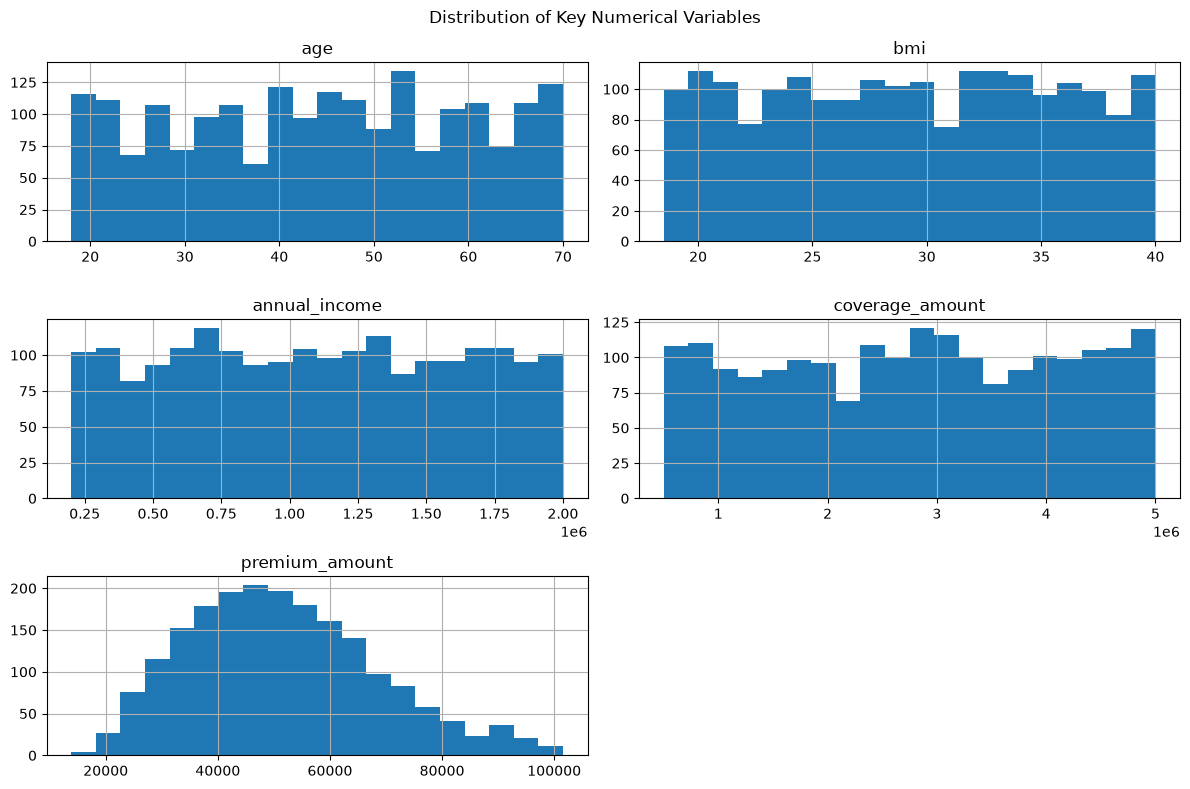

In [22]:
df[['age', 'bmi', 'annual_income', 'coverage_amount', 'premium_amount']].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribution of Key Numerical Variables')
plt.tight_layout()
plt.show()

### Detecting Potential Outliers

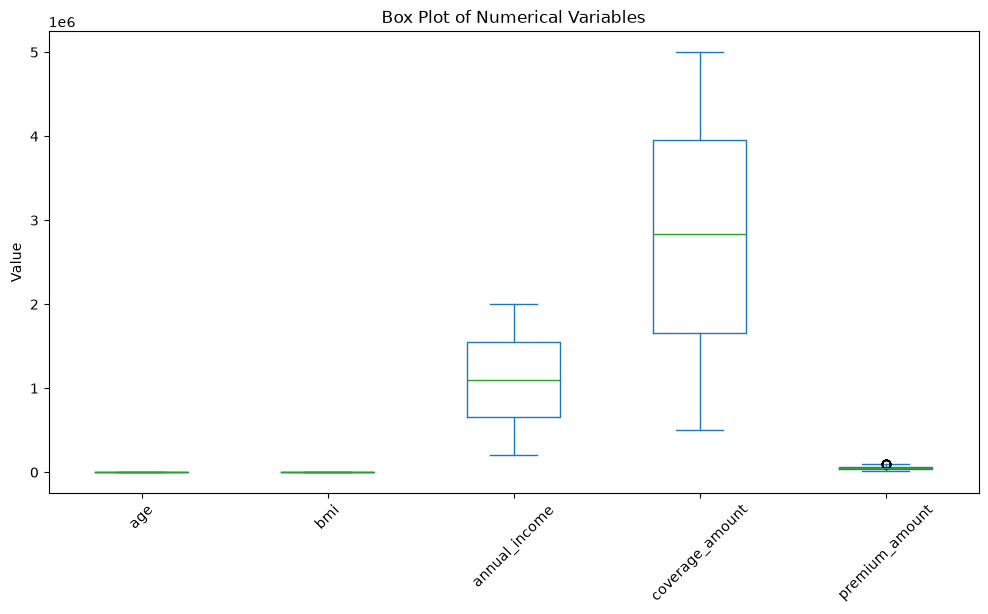

In [23]:
df[['age', 'bmi', 'annual_income', 'coverage_amount', 'premium_amount']].plot(
    kind='box',
    figsize=(12, 6)
)

plt.title('Box Plot of Numerical Variables')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

### Identifying Potential Outliers Using IQR

In [24]:
Q1 = df['premium_amount'].quantile(0.25)
Q3 = df['premium_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 38979.317500000005
Q3: 62345.39
IQR: 23366.072499999995
Lower Bound: 3930.2087500000125
Upper Bound: 97394.49875


In [25]:
potential_outliers = df[
    (df['premium_amount'] < lower_bound) |
    (df['premium_amount'] > upper_bound)
]

print("Number of potential outliers:", len(potential_outliers))

Number of potential outliers: 10


In [26]:
income_outliers = df[
    (df['annual_income'] < 2293.70) |
    (df['annual_income'] > 98335.22)
]

income_outliers[['annual_income']]

,annual_income
0,1818755
1,246901
2,1725304
3,566056
4,795350
...,...
1995,466496
1996,462328
1997,1127888
1998,1525039


In [27]:
income_outliers

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
0,56,38.9,1,No,Standard,3,1818755,651521,1,33181.19
1,69,21.7,0,No,Standard,1,246901,2376213,0,40770.68
2,46,27.8,0,No,Standard,4,1725304,4690198,0,76464.27
3,32,38.8,2,No,Basic,2,566056,3131866,1,41582.23
4,60,27.5,1,No,Standard,1,795350,3046946,1,46261.66
...,...,...,...,...,...,...,...,...,...,...
1995,37,21.0,1,No,Basic,1,466496,2620883,0,29673.20
1996,39,22.1,3,No,Standard,1,462328,2735300,1,43139.90
1997,28,18.5,4,Yes,Standard,4,1127888,2336079,1,51749.17
1998,44,34.0,3,No,Standard,2,1525039,1386358,1,40601.65


In [28]:
df['annual_income'].min(), df['annual_income'].max()

(np.int32(200903), np.int32(1999995))

In [29]:
Q1 = df['coverage_amount'].quantile(0.25)
Q3 = df['coverage_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['coverage_amount'] < lower_bound) |
    (df['coverage_amount'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 1652362.5
Q3: 3957255.0
IQR: 2304892.5
Lower Bound: -1804976.25
Upper Bound: 7414593.75
Number of potential outliers: 0


In [30]:
Q1 = df['premium_amount'].quantile(0.25)
Q3 = df['premium_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['premium_amount'] < lower_bound) |
    (df['premium_amount'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 38979.317500000005
Q3: 62345.39
IQR: 23366.072499999995
Lower Bound: 3930.2087500000125
Upper Bound: 97394.49875
Number of potential outliers: 10


In [31]:
df[['annual_income', 'premium_amount']].head()

,annual_income,premium_amount
0,1818755,33181.19
1,246901,40770.68
2,1725304,76464.27
3,566056,41582.23
4,795350,46261.66


In [32]:
df['annual_income'].equals(df['premium_amount'])

False

In [33]:
df['premium_amount'].describe()

count      2000.000000
mean      51534.069060
std       16894.082869
min       13860.460000
25%       38979.317500
50%       49896.765000
75%       62345.390000
max      101554.700000
Name: premium_amount, dtype: float64

In [34]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 31.0
Q3: 57.0
IQR: 26.0
Lower Bound: -8.0
Upper Bound: 96.0
Number of potential outliers: 0


In [35]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['bmi'] < lower_bound) |
    (df['bmi'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 23.9
Q3: 34.5
IQR: 10.600000000000001
Lower Bound: 7.9999999999999964
Upper Bound: 50.400000000000006
Number of potential outliers: 0


### Distribution of Numerical Variables

Before building machine learning models, it is important to understand how the numerical variables are distributed.

Histograms help us identify:
- The typical range of values
- The spread of the data
- Possible skewness
- Whether extreme values are present

We will examine the distributions of age, BMI, dependents, annual income, coverage amount, and premium amount.

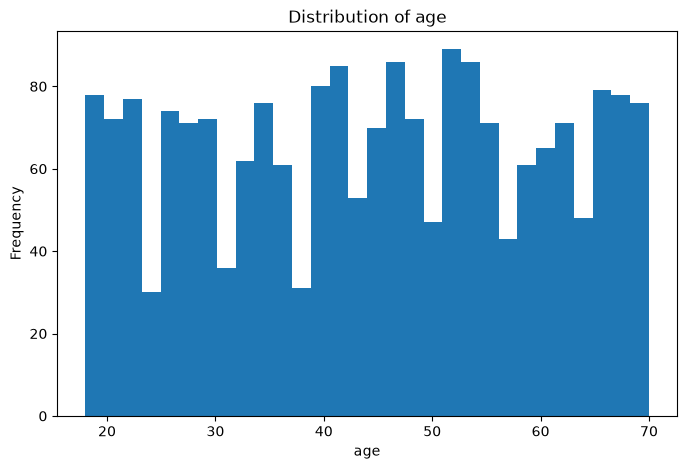

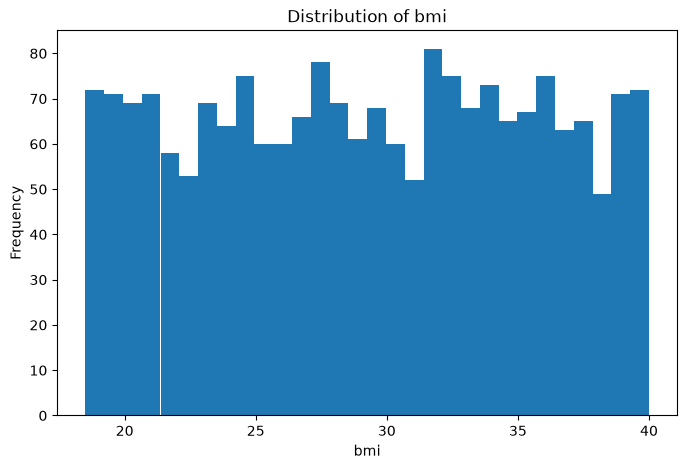

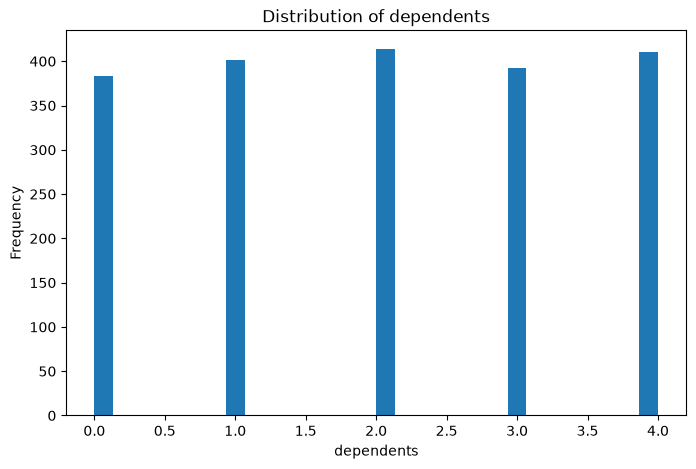

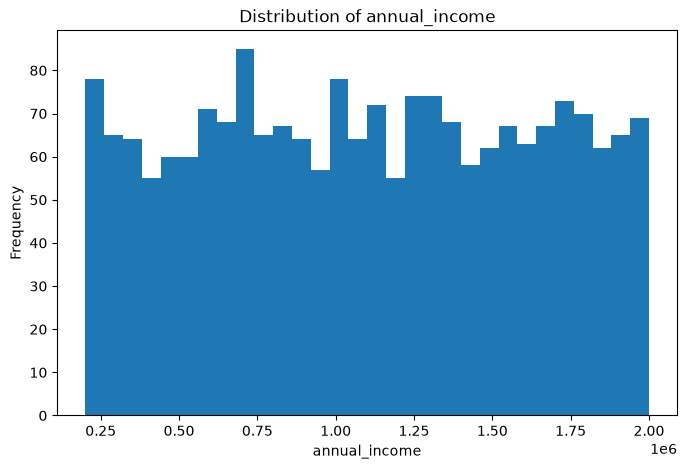

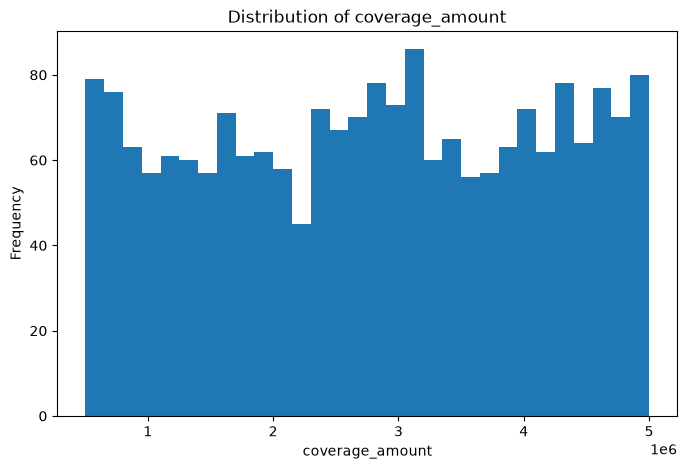

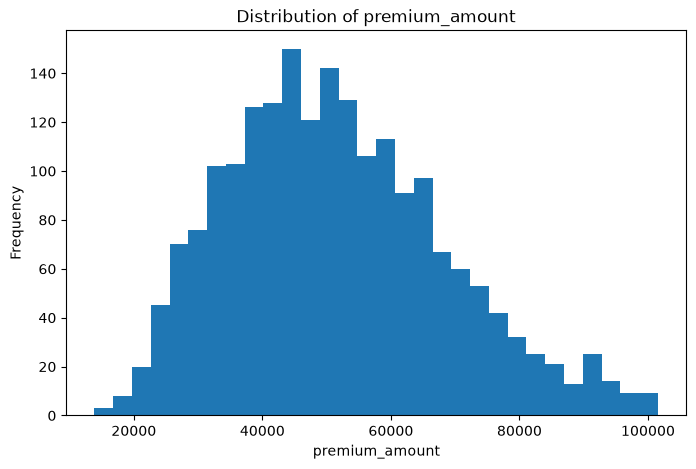

In [36]:
import matplotlib.pyplot as plt

numerical_columns = [
    'age',
    'bmi',
    'dependents',
    'annual_income',
    'coverage_amount',
    'premium_amount'
]

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()